# Milestone 1: Formula 1 podium prediction

**Course:** CSEN 903 Advanced Computer Lab, GUC, Winter 2026

**Team:**

**The question we answer:** for one driver in one race, will he finish in the top 3?

**When we answer it:** after qualifying and before the race starts. This moment is our *cutoff*. Anything recorded after it (finishing position, points, laps, pit stops, status, updated standings) is the answer sheet of the exam. If the model sees it, that is *data leakage* and the scores mean nothing.

**How this notebook is organised**

| Section | What happens | Brief objective |
|---|---|---|
| 0 | Setup and loading | Run-all requirement |
| 1 | Audit and EDA before cleaning | 1 |
| 2 | Cleaning, then EDA again | 1 |
| 3 | One joined table, one row per driver per race | 1 |
| 4 | The three data-engineering questions | 2 |
| 5 | Feature engineering with leakage tests | 3 |
| 6 | Split, preprocessing, order experiments | 3 |
| 7 | Models and evaluation | 4 |
| 8 | Feature-group ablation | 5 |
| 9 | Explainability (permutation importance, SHAP, LIME) | 6 |
| 10 | Inference function | Deliverable 7 |
| 11 | Summary, limitations, checklist | Report |

Every section follows the same pattern: what we do, why we do it, the code, then what we see in the output.

In [2]:
# --- Standard libraries ---
import os, sys, glob, random, hashlib, warnings, subprocess, importlib, time
warnings.filterwarnings('ignore')                      # keep the notebook output readable

# --- Data and plotting ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display


# --- Machine learning ---
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             precision_score, recall_score, confusion_matrix,
                             roc_curve, precision_recall_curve)

# --- Neural network ---
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')   # hide TensorFlow start-up messages
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping


# --- Explainability ---
import shap
import lime.lime_tabular

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)

# --- Reproducibility: one seed for everything ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print('pandas', pd.__version__, '| numpy', np.__version__, '| tensorflow', tf.__version__, '| shap', shap.__version__)

pandas 2.3.3 | numpy 2.1.3 | tensorflow 2.20.0 | shap 0.52.0


In [3]:
# --- One plotting style for the whole notebook, so every chart reads the same way ---
BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'     # main colours, used in this fixed order
LIGHT_BLUE, GREY, RED = '#9ec5f4', '#9a9a95', '#d03b3b'  # "before / reference", neutral, warning

plt.rcParams.update({
    'figure.dpi': 110, 'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e6e6e3', 'grid.linewidth': 0.8, 'axes.axisbelow': True,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'axes.labelsize': 10, 'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.frameon': False,
})

FIG_DIR = 'figures'              # every chart is also saved here, ready for the PDF report
os.makedirs(FIG_DIR, exist_ok=True)

def finish(fig, name):
    """Tidy the layout, save the chart as a PNG, and show it."""
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, name + '.png'), dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)

def pct(x, digits=1):
    """Format a share as a percentage string."""
    return f'{100 * x:.{digits}f}%'

In [4]:
import os
import pandas as pd

# The Kaggle dataset path
DATA_DIR = '/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020'

# The 14 table names
TABLES = [
    'circuits', 'constructors', 'constructor_results', 'constructor_standings', 
    'drivers', 'driver_standings', 'races', 'results', 'qualifying', 
    'lap_times', 'pit_stops', 'sprint_results', 'seasons', 'status'
]

# Load all tables into a dictionary as strings
raw = {}
for t in TABLES:
    file_path = os.path.join(DATA_DIR, t + '.csv')
    raw[t] = pd.read_csv(file_path, dtype=str, keep_default_na=False)

print('Successfully loaded tables:', len(raw))

Successfully loaded tables: 14


In [5]:
# To look at the first few rows of the drivers table
print(raw['drivers'].head())

# To look at the circuits table
print(raw['circuits'].head())

  driverId   driverRef number code  forename     surname         dob nationality                                             url
0        1    hamilton     44  HAM     Lewis    Hamilton  1985-01-07     British     http://en.wikipedia.org/wiki/Lewis_Hamilton
1        2    heidfeld     \N  HEI      Nick    Heidfeld  1977-05-10      German      http://en.wikipedia.org/wiki/Nick_Heidfeld
2        3     rosberg      6  ROS      Nico     Rosberg  1985-06-27      German       http://en.wikipedia.org/wiki/Nico_Rosberg
3        4      alonso     14  ALO  Fernando      Alonso  1981-07-29     Spanish    http://en.wikipedia.org/wiki/Fernando_Alonso
4        5  kovalainen     \N  KOV    Heikki  Kovalainen  1981-10-19     Finnish  http://en.wikipedia.org/wiki/Heikki_Kovalainen
  circuitId   circuitRef                            name      location    country       lat      lng  alt                                                url
0         1  albert_park  Albert Park Grand Prix Circuit     Melbourn

# 1. Audit and EDA before cleaning
Before we change anything we want to answer a very basic question: **"WHAT EXACTLY IS IN THE DATASET FILES AND WHAT IS WRONG WITH THESE FILES ?"**. Since EDA cannot be done by looking at the data by eye, so every statement in this section comes from code and has a table or a chart.

## 1.1 What do the 14 tables look like?
**What we do**: count rows and columns per table, and count the two kinds of placeholder for "missing": the text \N and the empty string.

**Why**: this tells us where the data lives (which tables are big), which tables need cleaning, and which table might be potentially our modelling table.

,table,rows,columns,cells equal to \N,empty cells
0,lap_times,589081,6,0,0
1,driver_standings,34863,7,0,0
2,results,26759,18,122887,0
3,constructor_standings,13391,7,0,0
4,constructor_results,12625,5,12608,0
5,pit_stops,11371,7,0,0
6,qualifying,10494,9,11600,68
7,races,1125,18,11349,0
8,drivers,861,9,1559,0
9,sprint_results,360,16,73,0


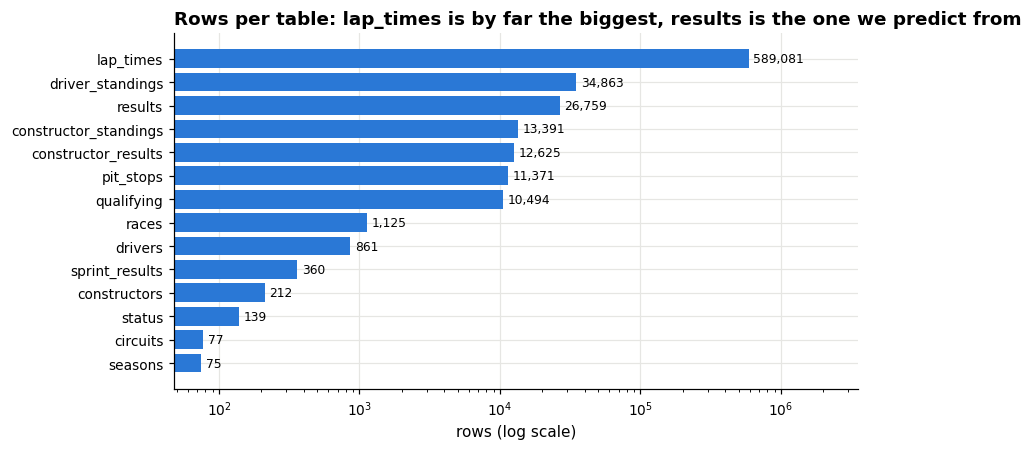

In [6]:
# One line per table: its size and how many placeholder cells it contains
overview = pd.DataFrame([{
    'table': t,
    'rows': len(df),
    'columns': df.shape[1],
    r'cells equal to \N': int((df == '\\N').sum().sum()),
    'empty cells': int((df == '').sum().sum()),
} for t, df in raw.items()]).sort_values('rows', ascending=False).reset_index(drop=True)
display(overview)

# Bar chart of the table sizes. The axis is logarithmic because lap_times is about 20 times bigger than results
fig, ax = plt.subplots(figsize=(8, 4.2))
o = overview.sort_values('rows')
bars = ax.barh(o['table'], o['rows'], color=BLUE)
ax.set_xscale('log')
ax.bar_label(bars, labels=[f'{v:,}' for v in o['rows']], padding=3, fontsize=8)
ax.set_xlabel('rows (log scale)')
ax.set_title('Rows per table: lap_times is by far the biggest, results is the one we predict from')
ax.set_xlim(right=o['rows'].max() * 6)
finish(fig, '01_rows_per_table')

## 1.2 How the tables link together

Now that subsection 1.1 told us what tables exist and how large they are, subsection 1.2 answers the next critical question: 
"**HOW ARE THESE 14 TABLES CONNECTED TO EACH OTHER ?**" 
This is exactly what we are answering in this subsection. 

**Why:** We know that the data is relational. Before joining we need to know which column identifies a row in each table (its primary key) and which columns point to another table (foreign keys). We write both down once, here, and the table below is our map for the rest of the notebook.

This is extremely important because our final modeling dataset will have to combine information from several tables. If we don't understand the keys and relationships first, we can easily create incorrect joins, duplicate rows, or lose observations.

In [7]:
# Primary key of every table, and every foreign key (child column -> parent table)
PRIMARY_KEYS = {
    'circuits': ['circuitId'], 'constructors': ['constructorId'], 'drivers': ['driverId'],
    'races': ['raceId'], 'seasons': ['year'], 'status': ['statusId'],
    'results': ['resultId'], 'qualifying': ['qualifyId'], 'sprint_results': ['resultId'],
    'driver_standings': ['driverStandingsId'], 'constructor_standings': ['constructorStandingsId'],
    'constructor_results': ['constructorResultsId'],
    'lap_times': ['raceId', 'driverId', 'lap'],      # composite key: no single id column
    'pit_stops': ['raceId', 'driverId', 'stop'],     # composite key
}
FOREIGN_KEYS = [  # (child table, column, parent table)
    ('races', 'circuitId', 'circuits'), ('races', 'year', 'seasons'),
    ('results', 'raceId', 'races'), ('results', 'driverId', 'drivers'),
    ('results', 'constructorId', 'constructors'), ('results', 'statusId', 'status'),
    ('qualifying', 'raceId', 'races'), ('qualifying', 'driverId', 'drivers'), ('qualifying', 'constructorId', 'constructors'),
    ('sprint_results', 'raceId', 'races'), ('sprint_results', 'driverId', 'drivers'),
    ('sprint_results', 'constructorId', 'constructors'), ('sprint_results', 'statusId', 'status'),
    ('driver_standings', 'raceId', 'races'), ('driver_standings', 'driverId', 'drivers'),
    ('constructor_standings', 'raceId', 'races'), ('constructor_standings', 'constructorId', 'constructors'),
    ('constructor_results', 'raceId', 'races'), ('constructor_results', 'constructorId', 'constructors'),
    ('lap_times', 'raceId', 'races'), ('lap_times', 'driverId', 'drivers'),
    ('pit_stops', 'raceId', 'races'), ('pit_stops', 'driverId', 'drivers'),
]

# The same information as one readable table: for each table, its key and the tables it points to
key_map = pd.DataFrame({
    'primary key': {t: ' + '.join(key) for t, key in PRIMARY_KEYS.items()},
    'points to (foreign keys)': {t: ', '.join(parent for child, _, parent in FOREIGN_KEYS if child == t) or '(nothing)' for t in PRIMARY_KEYS},
})
display(key_map)

,primary key,points to (foreign keys)
circuits,circuitId,(nothing)
constructors,constructorId,(nothing)
drivers,driverId,(nothing)
races,raceId,"circuits, seasons"
seasons,year,(nothing)
status,statusId,(nothing)
results,resultId,"races, drivers, constructors, status"
qualifying,qualifyId,"races, drivers, constructors"
sprint_results,resultId,"races, drivers, constructors, status"
driver_standings,driverStandingsId,"races, drivers"


**How to read it:** For example, `results` points to `races`, `drivers`, `constructors` and `status`. So one result row tells us which race, which driver, which team and how the race ended, but only as id numbers. The names and dates live in those four tables, and that is why we need joins. `races` in turn points to `circuits`, which is the "multi-hop" join: results to races to circuits.

## 1.3 Missing values: where and why

**What we do:** In this subsection, we answer a very important question: **"Where exactly are the missing values, how common are they, and most importantly are they missing randomly or for a reason?"**. So, for every column that contains a placeholder, compute the share of rows that are missing.

**Why:** a missing value can mean very different things. Sometimes the fact does not exist (a driver who retired has no finishing time). Sometimes the fact was never recorded (old seasons). We need to know which, because it decides how we treat it later. 

So, we're trying to distinguish:

*Missing because something wasn't recorded*

        vs.
*Missing because the value genuinely doesn't exist*

        vs.
*Missing because of historical/data-format differences*

Columns with at least one placeholder: 30


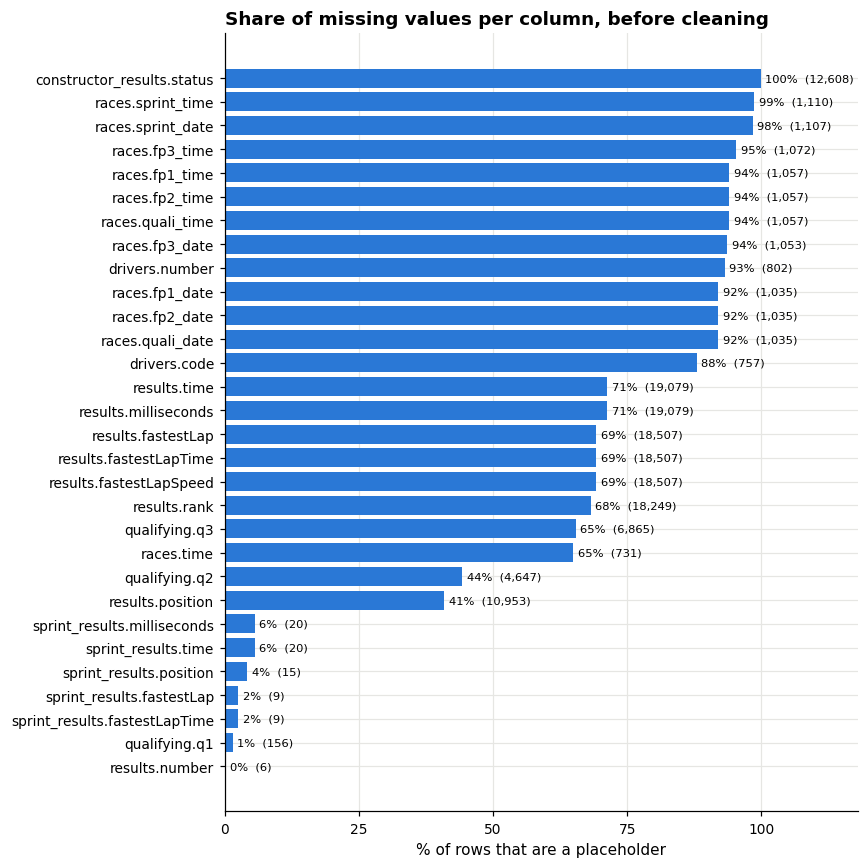

In [8]:
# For every column of every table: how many cells are a placeholder (\N or empty)?
missing_rows = []
for t, df in raw.items():
    for c in df.columns:
        n = int((df[c] == '\\N').sum() + (df[c] == '').sum())
        if n:
            missing_rows.append({'table': t, 'column': c, 'missing': n, 'share': n / len(df)})
missing_before = pd.DataFrame(missing_rows).sort_values('share')
print('Columns with at least one placeholder:', len(missing_before))

# One bar per column that has placeholders, labelled with the share and the count
fig, ax = plt.subplots(figsize=(8, 8))
labels = missing_before['table'] + '.' + missing_before['column']
bars = ax.barh(labels, missing_before['share'] * 100, color=BLUE)
ax.bar_label(bars, labels=[f'{s:.0%}  ({n:,})' for s, n in zip(missing_before['share'], missing_before['missing'])],
             padding=3, fontsize=7.5)
ax.set_xlim(0, 118); ax.set_xticks([0, 25, 50, 75, 100]); ax.set_xlabel('% of rows that are a placeholder')
ax.set_title('Share of missing values per column, before cleaning')
finish(fig, '03_missing_per_column')

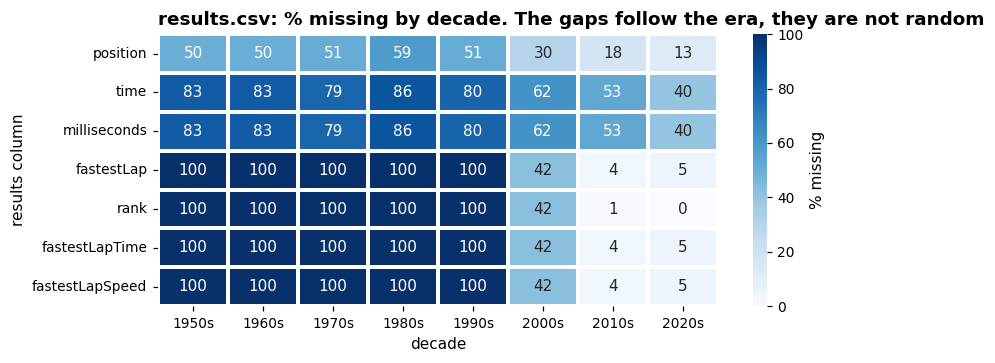

In [9]:
# Is the missingness random, or does it depend on the season? One heatmap answers that.
r_year = raw['results'].merge(raw['races'][['raceId', 'year']], on='raceId')
r_year['decade'] = (r_year['year'].astype(int) // 10 * 10).astype(str) + 's'
result_cols = ['position', 'time', 'milliseconds', 'fastestLap', 'rank', 'fastestLapTime', 'fastestLapSpeed']
heat = pd.DataFrame({c: (r_year[c] == '\\N').groupby(r_year['decade']).mean() for c in result_cols}).T * 100

fig, ax = plt.subplots(figsize=(8, 3.4))
sns.heatmap(heat, annot=True, fmt='.0f', cmap='Blues', cbar_kws={'label': '% missing'}, linewidths=1.5,
            linecolor='white', vmin=0, vmax=100, ax=ax)
ax.set_xlabel('decade'); ax.set_ylabel('results column'); ax.grid(False)
ax.set_title('results.csv: % missing by decade. The gaps follow the era, they are not random')
finish(fig, '04_missing_by_decade')

**What we see**
- `position`, `time` and `milliseconds` are missing for cars that did not finish. That is not an error: a car that retired has no finishing time. The share shrinks over the decades because modern cars break down less.
- The fastest-lap columns are 100% missing before the 2000s and almost complete after. They were simply not recorded in old seasons.
- `q2` and `q3` are missing for many rows because of how knockout qualifying works: slow drivers are eliminated and never set a time in the later rounds.
- Almost all of these columns are filled in after the race, so they can never be features anyway. The missing values that matter for us are in `qualifying` and `grid`, and we look at those next.

So, we can observe that: **"Missingness has a pattern throughout the years (historical pattern)"**
This is an important conclusion that tells us that missingness is not always random, so, needs a certain type of cleaning (not just dropping with no reason).

In conclusion, we can say that missingness in this dataset is often systematic and meaningful. It reflects race outcomes, qualifying progression, and historical differences in data recording. Therefore, we must not blindly impute or delete missing values. We need column-specific treatment, especially for pre-race features such as qualifying information.

## 1.4 Primary keys

**What we do:** check that the key of every table is unique and never missing.

**Why:** a key identifies one row. If two rows share a key, a join multiplies rows without telling us.

In [10]:
# For each table: are there duplicate keys, and is any key cell a placeholder?
pk_report = []
for t, key in PRIMARY_KEYS.items():
    df = raw[t]
    pk_report.append({
        'table': t, 'primary key': ' + '.join(key), 'rows': len(df),
        'duplicate keys': int(df.duplicated(key).sum()),
        'missing keys': int(df[key].isin(['\\N', '']).any(axis=1).sum()),
    })
pk_report = pd.DataFrame(pk_report)
pk_report['OK'] = (pk_report['duplicate keys'] == 0) & (pk_report['missing keys'] == 0)
display(pk_report)
# Stop the notebook here if a key is broken: no join after this point could be trusted
assert pk_report['OK'].all(), 'A primary key is broken'
print('All 14 primary keys are unique and non-null.')

,table,primary key,rows,duplicate keys,missing keys,OK
0,circuits,circuitId,77,0,0,True
1,constructors,constructorId,212,0,0,True
2,drivers,driverId,861,0,0,True
3,races,raceId,1125,0,0,True
4,seasons,year,75,0,0,True
5,status,statusId,139,0,0,True
6,results,resultId,26759,0,0,True
7,qualifying,qualifyId,10494,0,0,True
8,sprint_results,resultId,360,0,0,True
9,driver_standings,driverStandingsId,34863,0,0,True


All 14 primary keys are unique and non-null.


## 1.5 Foreign keys
**What we do**: for every link in the table of 1.2, look for "orphans": values in the child table that do not exist in the parent table. This is an anti-join.

**Why**: an orphan row would be dropped by an inner join (we lose data) or get empty columns in a left join.

In [11]:
fk_report = []
for child, col, parent in FOREIGN_KEYS:
    orphans = ~raw[child][col].isin(raw[parent][col])          # anti-join: child value not found in parent
    fk_report.append({'child table': child, 'column': col, 'parent table': parent,
                      'rows checked': len(raw[child]), 'orphans': int(orphans.sum())})
fk_report = pd.DataFrame(fk_report)
display(fk_report)
assert fk_report['orphans'].sum() == 0, 'A foreign key does not reconcile'
print(f'All {len(fk_report)} foreign-key links reconcile: 0 orphans.')

,child table,column,parent table,rows checked,orphans
0,races,circuitId,circuits,1125,0
1,races,year,seasons,1125,0
2,results,raceId,races,26759,0
3,results,driverId,drivers,26759,0
4,results,constructorId,constructors,26759,0
5,results,statusId,status,26759,0
6,qualifying,raceId,races,10494,0
7,qualifying,driverId,drivers,10494,0
8,qualifying,constructorId,constructors,10494,0
9,sprint_results,raceId,races,360,0


All 23 foreign-key links reconcile: 0 orphans.


**What we see**: every one of the 23 links is clean. The dataset is well built as a database. Its problems are in the meaning of the rows, which is what the next checks are about.

## 1.6 Is there really one row per driver per race?
**Why**: our unit of analysis is "one driver entering one race". resultId is unique, but that is not the same thing. We need the pair (raceId, driverId) to be unique.

Rows that share (raceId, driverId) with another row: 176
Driver-race pairs affected: 85
Rows per affected pair: {2: 79, 3: 6}


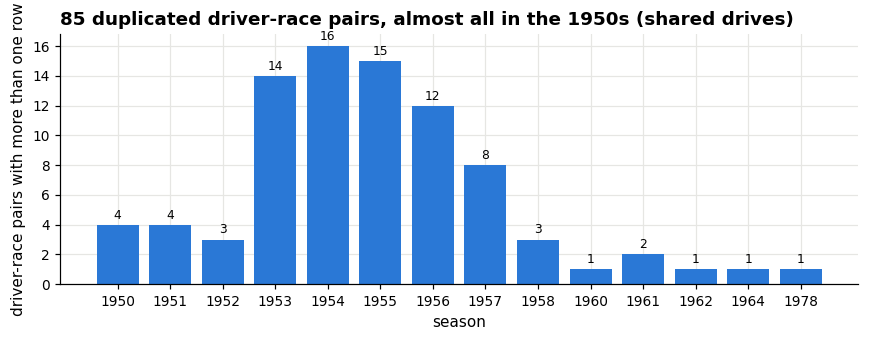

,resultId,year,name,driverId,number,grid,positionText,positionOrder,points,laps
18894,18895,1956,Argentine Grand Prix,579,30,1,R,13,0,22
20266,20267,1956,Argentine Grand Prix,579,34,3,1,1,5,98


In [12]:
# Add the season and the race name to every result row
res_raw = raw['results'].merge(raw['races'][['raceId', 'year', 'name']], on='raceId')
res_raw['year'] = res_raw['year'].astype(int)

# keep=False marks ALL rows of a repeated pair, not only the second one
is_dup = res_raw.duplicated(['raceId', 'driverId'], keep=False)
dup_rows = res_raw[is_dup]
n_groups = dup_rows.drop_duplicates(['raceId', 'driverId']).shape[0]
print(f'Rows that share (raceId, driverId) with another row: {len(dup_rows)}')
print(f'Driver-race pairs affected: {n_groups}')
print('Rows per affected pair:', dup_rows.groupby(['raceId', 'driverId']).size().value_counts().to_dict())

# Count each affected driver-race pair once, per season
by_year = dup_rows.drop_duplicates(['raceId', 'driverId']).groupby('year').size()
fig, ax = plt.subplots(figsize=(8, 3.2))
bars = ax.bar(by_year.index.astype(str), by_year.values, color=BLUE)
ax.bar_label(bars, fontsize=8, padding=2)
ax.set_ylabel('driver-race pairs with more than one row'); ax.set_xlabel('season')
ax.set_title(f'{n_groups} duplicated driver-race pairs, almost all in the 1950s (shared drives)')
finish(fig, '05_duplicates_by_year')

# One real example: Fangio at the 1956 Argentine Grand Prix
fangio = raw['drivers'].loc[raw['drivers']['driverRef'] == 'fangio', 'driverId'].iloc[0]
example = res_raw[(res_raw['driverId'] == fangio) & (res_raw['year'] == 1956) & (res_raw['name'] == 'Argentine Grand Prix')]
display(example[['resultId', 'year', 'name', 'driverId', 'number', 'grid', 'positionText', 'positionOrder', 'points', 'laps']])

**What we see**
- 85 driver-race pairs have more than one row (79 pairs with two rows, 6 with three), 176 rows in total.
- They sit in 1950 to 1964, plus one case in 1978. This matches what we know about the old shared-drives: in early F1, a driver whose car broke could take over a team mate's car, and the data stores one row per car he drove.
- The example shows it. Fangio started the 1956 Argentine GP from pole in car 30 and retired. He then took over car 34 (which had started 3rd) and won. Two rows, one driver, one race.

So, if we ask ourselves: 

**"Does the results table actually match our required ML grain of one row per (raceId, driverId)?"**

The answer is: **Not completely. Historical shared drives create 85 affected driver-race pairs, so this must be handled deliberately during cleaning.**

## 1.7 How the sport changed over 75 seasons

**Why:** our table covers 1950 to 2024. If the sport changed a lot, a pattern from 1960 may not hold in 2024. These charts are the evidence we point to later when we choose the training window and decide how to treat missing qualifying data.

So, we're dealing with 75 year of Formula 1. That's actually a huge period!!

F1 in 1950 is not statistically equivalent to F1 in 2024. There were major changes in: number of races per season, number of cars entering races, reliability, qualifying systems, race procedures, regulations, number of available drivers, and data recording practices.

Therefore, before building an ML model, we need to know:

**Are we treating 75 years of historical data as if they were generated under one consistent system?**

This subsection give us evidence

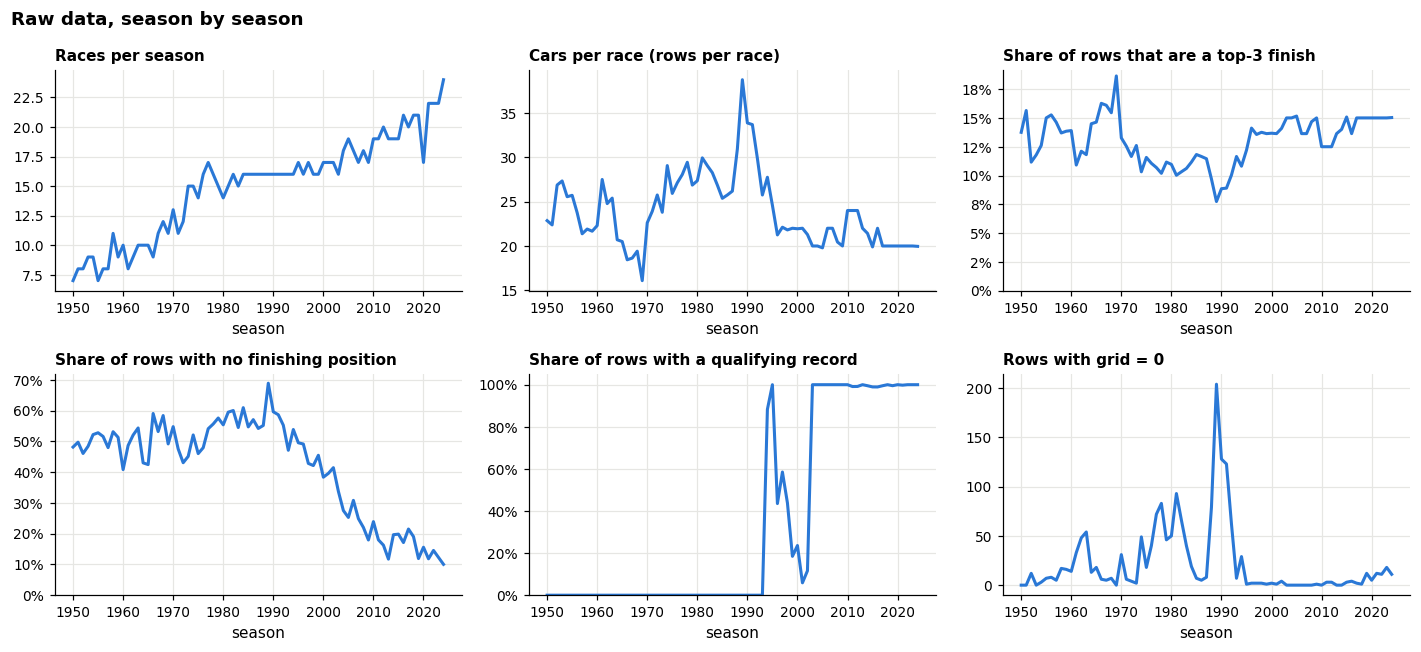

First season with any qualifying record: 1994


year,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006
quali_coverage,88%,100%,44%,59%,44%,18%,24%,6%,12%,100%,100%,100%,100%


In [13]:
def season_profile(results, qualifying):
    """One row per season with the numbers we want to track. Used before AND after cleaning."""
    r = results.copy()
    r['is_podium'] = r['positionOrder'].astype(float) <= 3
    # Use the aggregated driver-level classification if available (see section 2.5).
    # Otherwise, derive classification from each raw result row.
    if 'classified' not in r.columns:
        r['classified'] = r['positionText'].astype(str).str.isdigit()
    else:
        r['classified'] = r['classified'].astype(bool)
    r['grid0'] = r['grid'].astype(float) == 0
    # does this (race, driver) pair have a row in the qualifying table?
    q_keys = set(zip(qualifying['raceId'].astype(int), qualifying['driverId'].astype(int)))
    r['has_quali'] = [k in q_keys for k in zip(r['raceId'].astype(int), r['driverId'].astype(int))]
    # one row per season
    g = r.groupby('year')
    return pd.DataFrame({
        'races': g['raceId'].nunique(),
        'rows_per_race': g.size() / g['raceId'].nunique(),
        'podium_share': g['is_podium'].mean(),
        'not_classified_share': 1 - g['classified'].mean(),
        'quali_coverage': g['has_quali'].mean(),
        'grid0_rows': g['grid0'].sum(),
    })

profile_before = season_profile(res_raw, raw['qualifying'])

# Six small charts, one per measurement. Shares are shown as percentages
panels = [('races', 'Races per season', 'races'),
          ('rows_per_race', 'Cars per race (rows per race)', 'rows'),
          ('podium_share', 'Share of rows that are a top-3 finish', 'share'),
          ('not_classified_share', 'Share of rows with no finishing position', 'share'),
          ('quali_coverage', 'Share of rows with a qualifying record', 'share'),
          ('grid0_rows', 'Rows with grid = 0', 'rows')]
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, (col, title, unit) in zip(axes.ravel(), panels):
    ax.plot(profile_before.index, profile_before[col], color=BLUE, lw=2)
    ax.set_title(title, fontsize=10); ax.set_xlabel('season')
    if unit == 'share':
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
        ax.set_ylim(bottom=0)
fig.suptitle('Raw data, season by season', x=0.01, ha='left', weight='bold')
finish(fig, '06_season_profile_before')

print('First season with any qualifying record:', int(profile_before.index[profile_before['quali_coverage'] > 0].min()))
display(profile_before.loc[1994:2006, ['quali_coverage']].T.style.format('{:.0%}').set_caption('Qualifying coverage, 1994 to 2006'))

**What we see**
- **Calendar:** 7 races in 1950, 24 in 2024.
- **Field size:** 25 to 30 rows per race in the 1970s and 1980s, with a peak of almost 39 in 1989, and about 20 since the late 1990s. Those extra rows are mostly cars that showed up and failed to qualify.
- **Podium share:** always 3 per race, so the share moves with field size (about 8% in 1989, 15% now). Podiums are rare, which is why accuracy is a bad metric for this task: a model that always says "no" would be about 86% accurate and useless.
- **Reliability:** until about 1990, half of the rows or more have no finishing position. Today it is under 20%. A good grid slot was worth less when cars broke down so often.
- **Qualifying coverage:** the qualifying table starts in 1994. It is nearly complete in 1994 and 1995, patchy from 1996 to 2002 (as low as 6%), and complete from 2003. This is the "qualifying-coverage drift" the brief warns about, and it is bigger than we expected.
- **Grid = 0:** many rows up to the mid 1990s, then a small rise again after 2015. A grid position of 0 does not exist on a real grid, so this needs an explanation. We look into it in 1.8.

## 1.8 Columns that need a closer look

**What we do:** look at the value ranges and categories of the columns we plan to use.

**Why:** We need to check categories for inconsistent spellings and numeric columns for impossible values before trusting them.

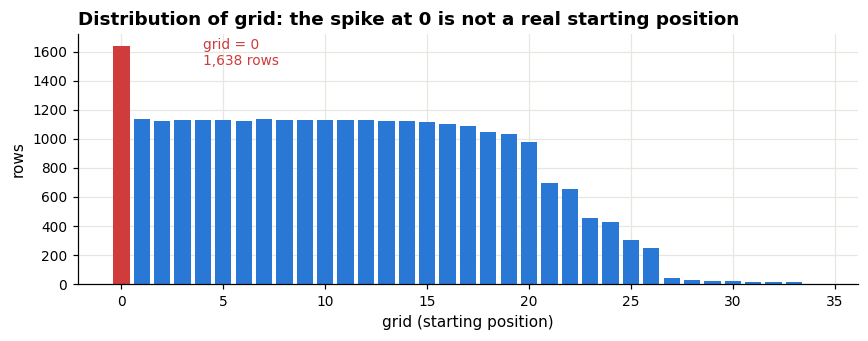

raced,completed 0 laps,completed at least 1 lap,All
outcome,,,
disqualified,6,0,6
excluded,7,0,7
failed to qualify,1348,0,1348
finished (has a position),0,60,60
retired,2,12,14
withdrawn,203,0,203
All,1566,72,1638


Seasons of the grid = 0 rows that completed laps: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


In [14]:
# --- (a) grid: a starting position of 0 is impossible on a real grid ---
grid = res_raw['grid'].astype(int)
fig, ax = plt.subplots(figsize=(8, 3.2))
# how many rows start from each grid value. The bar at 0 is drawn in red
counts = grid.value_counts().sort_index()
ax.bar(counts.index, counts.values, color=[RED if g == 0 else BLUE for g in counts.index])
ax.annotate(f'grid = 0\n{counts.loc[0]:,} rows', xy=(0, counts.loc[0]), xytext=(4, counts.loc[0] * 0.92), fontsize=9, color=RED)
ax.set_xlabel('grid (starting position)'); ax.set_ylabel('rows')
ax.set_title('Distribution of grid: the spike at 0 is not a real starting position')
finish(fig, '07_grid_distribution')

# Who are the grid = 0 rows? positionText tells us how the race ended for them.
POSITION_CODES = {'R': 'retired', 'D': 'disqualified', 'E': 'excluded', 'W': 'withdrawn',
                  'F': 'failed to qualify', 'N': 'not classified'}
res_raw['outcome'] = res_raw['positionText'].map(POSITION_CODES).fillna('finished (has a position)')
# Take only the grid = 0 rows and split them by whether the car completed any lap
grid0 = res_raw[grid == 0].copy()
grid0['raced'] = np.where(grid0['laps'].astype(int) > 0, 'completed at least 1 lap', 'completed 0 laps')
display(pd.crosstab(grid0['outcome'], grid0['raced'], margins=True))
print('Seasons of the grid = 0 rows that completed laps:', sorted(int(y) for y in grid0.loc[grid0['raced'] == 'completed at least 1 lap', 'year'].unique()))

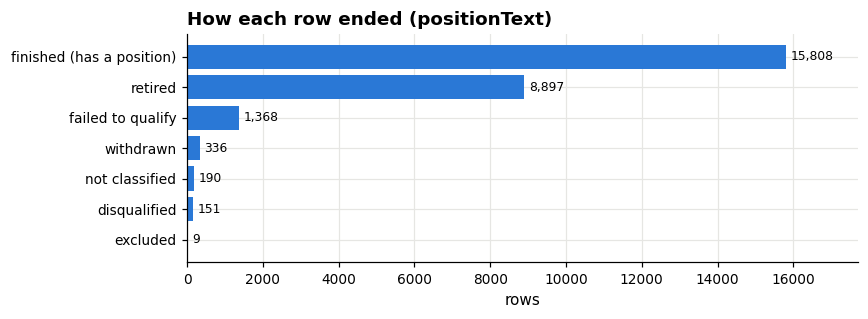

['Argentina', 'Australia', 'Austria', 'Azerbaijan', 'Bahrain', 'Belgium', 'Brazil', 'Canada', 'China', 'France', 'Germany', 'Hungary', 'India', 'Italy', 'Japan', 'Korea', 'Malaysia', 'Mexico', 'Monaco', 'Morocco', 'Netherlands', 'Portugal', 'Qatar', 'Russia', 'Saudi Arabia', 'Singapore', 'South Africa', 'Spain', 'Sweden', 'Switzerland', 'Turkey', 'UAE', 'UK', 'USA', 'United States']

Circuit countries that look like the same place: ['USA', 'United States']
Unique driver nationalities:
['American', 'American-Italian', 'Argentine', 'Argentine-Italian', 'Argentinian ', 'Australian', 'Austrian', 'Belgian', 'Brazilian', 'British', 'Canadian', 'Chilean', 'Chinese', 'Colombian', 'Czech', 'Danish', 'Dutch', 'East German', 'Finnish', 'French', 'German', 'Hungarian', 'Indian', 'Indonesian', 'Irish', 'Italian', 'Japanese', 'Liechtensteiner', 'Malaysian', 'Mexican', 'Monegasque', 'New Zealander', 'Polish', 'Portuguese', 'Rhodesian', 'Russian', 'South African', 'Spanish', 'Swedish', 'Swiss', 'Thai'

In [15]:
# --- (b) positionText codes over the whole table ---
codes = res_raw['outcome'].value_counts()
fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.barh(codes.index[::-1], codes.values[::-1], color=BLUE)
ax.bar_label(bars, labels=[f'{v:,}' for v in codes.values[::-1]], padding=3, fontsize=8)
ax.set_xlim(right=codes.max() * 1.12); ax.set_xlabel('rows')
ax.set_title('How each row ended (positionText)')
finish(fig, '08_position_codes')

# --- (c) inconsistent categories ---
countries = sorted(raw['circuits']['country'].unique())
print(countries)
print('\nCircuit countries that look like the same place:', [c for c in countries if c in ('USA', 'United States')])

nat = raw['drivers']['nationality'].astype(str)
print('Unique driver nationalities:')
print(sorted(nat.unique()))

print('\nDriver nationalities with spaces at the start or end:', sorted(set(nat[nat != nat.str.strip()])))
print('Hyphenated nationality labels:',sorted(n for n in nat.unique() if '-' in n))

# --- (d) time formats stored as text ---
print('\nExamples of time columns (all stored as text):')
print('  qualifying.q1        :', raw['qualifying']['q1'].iloc[:3].tolist())
print('  results.time         :', raw['results']['time'].iloc[:3].tolist(), '<- winner has a full time, others a gap')
print('  pit_stops.duration   :', sorted(raw['pit_stops']['duration'], key=len)[0], 'and', sorted(raw['pit_stops']['duration'], key=len)[-1])
print('  races.date           :', raw['races']['date'].iloc[0])

**What we see**
- **Grid = 0** covers 1,638 rows. Most of them (1,566) completed zero laps: they failed to qualify, withdrew, or were excluded before the race. They never had a place on the grid.
- 72 grid = 0 rows did complete laps, all from 2015 onwards. These are **pit-lane starts**: the car starts from the pit lane instead of a grid slot, usually after a penalty, and the dataset writes that as 0.
- So 0 means "no grid slot", never "ahead of pole". If we left it as a number, a model would read 0 as the best position there is.
- **Categories:** `circuits.country` has both "USA" and "United States". `drivers.nationality` has "Argentine" and "Argentinian " (with a space at the end). Both would break the home-race match in Question 2.
- **Times** are text in three different shapes (`1:26.572`, `26.898`, `+5.478`). They need to become numbers.

## 1.9 Audit summary

| # | Problem found | Evidence | Fixed in |
|---|---|---|---|
| 1 | Two placeholders for missing: `\N` and empty text | 1.1, 1.3 | 2.1 |
| 2 | Dates, numbers and lap times stored as text | 1.8 | 2.2 |
| 3 | Inconsistent country and nationality spellings | 1.8 | 2.2 |
| 4 | Indianapolis 500 rows (a different kind of race) | 2.3 | 2.3 |
| 5 | Rows for cars that never had a grid slot | 1.7, 1.8 | 2.4 |
| 6 | Grid = 0 used for pit-lane starts | 1.8 | 2.4 |
| 7 | 85 driver-race pairs with more than one row | 1.6 | 2.5 |
| 8 | Qualifying data missing before 1994 and patchy to 2002 | 1.7 | handled in features (5) and training window (7) |

Keys are fine: 14 primary keys valid, 23 foreign keys with 0 orphans.

# 2. Cleaning

Rule for this whole section: `raw` is never touched. We work on `clean`, a copy.

## 2.1 Placeholders become real missing values

**Why:** `\N` is text. As long as it is in a column, pandas treats the whole column as text and no maths works on it. Turning it into NaN lets pandas recognise it as "missing".

In [16]:
clean = {t: df.copy() for t, df in raw.items()}          # the originals in `raw` stay untouched

for t in clean:
    clean[t] = clean[t].replace({'\\N': np.nan, '': np.nan})

placeholders_left = sum(int((df == '\\N').sum().sum() + (df == '').sum().sum()) for df in clean.values())
nan_now = sum(int(df.isna().sum().sum()) for df in clean.values())
placeholders_before = int(overview[r'cells equal to \N'].sum() + overview['empty cells'].sum())
print(f'Placeholders before: {placeholders_before:,}   after: {placeholders_left}   NaN cells now: {nan_now:,}')
assert placeholders_left == 0 and nan_now == placeholders_before      # nothing lost, nothing invented

Placeholders before: 160,144   after: 0   NaN cells now: 160,144


## 2.2 Semantic typing

**What we do:** give every column the type that matches its meaning.
- ids, positions, points, laps: numbers
- dates: real dates, so we can sort races in time and compute a driver's age
- lap times and durations like `1:26.572`: seconds as a number (86.572)
- text: trimmed, and the two spelling problems fixed

**Why:** 
- The raw CSV values do not necessarily have computational types that match their meaning.
- We explicitly defined a schema for numeric, date, and duration columns, then converted them accordingly.
- In particular, qualifying and lap times were converted from strings such as 1:26.572 into seconds so that mathematical operations and feature engineering are possible.
- We used errors='raise' so unexpected values would fail loudly rather than being silently converted into missing values.
- We also stripped text whitespace and applied the specific categorical normalizations identified during our EDA. 

In [17]:
def to_seconds(value):
    """'1:26.572' -> 86.572, '26.898' -> 26.898, '1:02:03.5' -> 3723.5, NaN stays NaN."""
    if pd.isna(value):
        return np.nan
    total = 0.0
    for part in str(value).split(':'):      # each ':' means "multiply what we have so far by 60"
        total = total * 60 + float(part)
    return total

SCHEMA = {   # num = numeric, date = calendar date, dur = duration text -> new column <name>_s in seconds
    'circuits': {'num': ['circuitId', 'lat', 'lng', 'alt']},
    'constructors': {'num': ['constructorId']},
    'constructor_results': {'num': ['constructorResultsId', 'raceId', 'constructorId', 'points']},
    'constructor_standings': {'num': ['constructorStandingsId', 'raceId', 'constructorId', 'points', 'position', 'wins']},
    'drivers': {'num': ['driverId', 'number'], 'date': ['dob']},
    'driver_standings': {'num': ['driverStandingsId', 'raceId', 'driverId', 'points', 'position', 'wins']},
    'races': {'num': ['raceId', 'year', 'round', 'circuitId'],
              'date': ['date', 'fp1_date', 'fp2_date', 'fp3_date', 'quali_date', 'sprint_date']},
    'results': {'num': ['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid', 'position',
                        'positionOrder', 'points', 'laps', 'milliseconds', 'fastestLap', 'rank',
                        'fastestLapSpeed', 'statusId'], 'dur': ['fastestLapTime']},
    'qualifying': {'num': ['qualifyId', 'raceId', 'driverId', 'constructorId', 'number', 'position'],
                   'dur': ['q1', 'q2', 'q3']},
    'lap_times': {'num': ['raceId', 'driverId', 'lap', 'position', 'milliseconds'], 'dur': ['time']},
    'pit_stops': {'num': ['raceId', 'driverId', 'stop', 'lap', 'milliseconds'], 'dur': ['duration']},
    'sprint_results': {'num': ['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid', 'position',
                               'positionOrder', 'points', 'laps', 'milliseconds', 'fastestLap', 'statusId'],
                       'dur': ['fastestLapTime']},
    'seasons': {'num': ['year']},
    'status': {'num': ['statusId']},
}

dtypes_before = {t: clean[t].dtypes.astype(str) for t in ('results', 'qualifying', 'races')}

for t, spec in SCHEMA.items():
    df = clean[t]
    for c in spec.get('num', []):
        df[c] = pd.to_numeric(df[c], errors='raise')                 # fails loudly on anything unexpected
    for c in spec.get('date', []):
        df[c] = pd.to_datetime(df[c], format='%Y-%m-%d', errors='raise')
    for c in spec.get('dur', []):
        df[c + '_s'] = df[c].map(to_seconds)                         # keep the text, add seconds next to it
    typed = set(spec.get('num', []) + spec.get('date', []))
    for c in df.columns:                                             # every column we did not convert is text
        if c not in typed and not c.endswith('_s') and not pd.api.types.is_numeric_dtype(df[c]):
            df[c] = df[c].str.strip()                                # remove stray spaces
    clean[t] = df

# Two spelling fixes found in the audit (1.8)
clean['circuits']['country'] = clean['circuits']['country'].replace({'United States': 'USA'})
clean['drivers']['nationality'] = clean['drivers']['nationality'].replace({'Argentinian': 'Argentine'})

# Show the effect on the two tables we use most
for t in ('results', 'qualifying'):
    after = clean[t].dtypes.astype(str)
    display(pd.DataFrame({'type before': dtypes_before[t], 'type after': after}).fillna('(new column)')
              .T.style.set_caption(f'{t}: column types before and after'))

,constructorId,driverId,fastestLap,fastestLapSpeed,fastestLapTime,fastestLapTime_s,grid,laps,milliseconds,number,points,position,positionOrder,positionText,raceId,rank,resultId,statusId,time
type before,object,object,object,object,object,(new column),object,object,object,object,object,object,object,object,object,object,object,object,object
type after,int64,int64,float64,float64,object,float64,int64,int64,float64,float64,float64,float64,int64,object,int64,float64,int64,int64,object


,constructorId,driverId,number,position,q1,q1_s,q2,q2_s,q3,q3_s,qualifyId,raceId
type before,object,object,object,object,object,(new column),object,(new column),object,(new column),object,object
type after,int64,int64,int64,int64,object,float64,object,float64,object,float64,int64,int64


In [18]:
# --- Checks on the typing step: do the converted numbers make sense? ---

# 1) Our own lap-time parser must agree with the milliseconds column that the dataset already provides.
lt = clean['lap_times']
assert np.allclose(lt['time_s'], lt['milliseconds'] / 1000, atol=0.0011), 'lap time parser disagrees with milliseconds'
ps = clean['pit_stops']
assert np.allclose(ps['duration_s'], ps['milliseconds'] / 1000, atol=0.0011), 'pit stop parser disagrees with milliseconds'
print(f'Parser check: {len(lt):,} lap times and {len(ps):,} pit stops match the milliseconds column exactly.')

# 2) Dates: every race has a date, no two races share one, and date order equals (year, round) order.
rc = clean['races'].sort_values('date')
assert rc['date'].notna().all() and rc['date'].is_unique
assert list(zip(rc['year'], rc['round'])) == sorted(zip(rc['year'], rc['round']))
print(f'Date check: {len(rc)} races from {rc["date"].min().date()} to {rc["date"].max().date()}, in a strict time order.')

# 3) Qualifying times: plausible range?
q = clean['qualifying']
print('\nQualifying lap times in seconds:')
display(q[['q1_s', 'q2_s', 'q3_s']].describe().loc[['count', 'min', '50%', 'max']].round(1))
odd = q[q['q1_s'] > 300].merge(clean['races'][['raceId', 'year', 'name']], on='raceId')
display(odd[['year', 'name', 'driverId', 'position', 'q1']].style.set_caption('Qualifying times above 5 minutes'))

print('Spelling fixes ->', 'countries:', 'United States' not in set(clean['circuits']['country']),
      '| nationalities:', 'Argentinian' not in set(clean['drivers']['nationality']))

Parser check: 589,081 lap times and 11,371 pit stops match the milliseconds column exactly.
Date check: 1125 races from 1950-05-13 to 2024-12-08, in a strict time order.

Qualifying lap times in seconds:


,q1_s,q2_s,q3_s
count,10338.0,5847.0,3629.0
min,53.9,53.6,53.4
50%,87.1,87.1,87.0
max,1002.6,132.5,129.8


,year,name,driverId,position,q1
0,1995,Japanese Grand Prix,87,24,16:42.640


Spelling fixes -> countries: True | nationalities: True


**What we see**
- Our text-to-seconds function gives exactly the same value as the dataset's own `milliseconds` column on 589,081 lap times and 11,371 pit stops. So we trust it on the qualifying times, where there is no milliseconds column to compare with.
- Race dates are complete and unique, and sorting by date gives the same order as sorting by (year, round). This matters a lot later: every "past races only" feature depends on a correct time order.
- Qualifying times run from about 54 seconds (the short Sakhir layout in 2020) to about 2.5 minutes, plus one entry of 16:42.640 at the 1995 Japanese GP. That one is clearly not a real flying lap. We do not delete it (it is one driver's real record of having no competitive time) but in Section 5 we cap the gap-to-fastest feature so one value like this cannot dominate.

## 2.3 The Indianapolis 500

**What we do:** remove the 11 Indianapolis 500 races (1950 to 1960).

**Why:** from 1950 to 1960 the Indy 500 counted for the world championship, but it was an American oval race with its own cars, rules and drivers. The check below shows how little its drivers overlap with the rest of F1. Keeping it would add 33-car grids of drivers with no other F1 history, and it would also distort Question 2 because nearly every starter was American racing at home.

Indianapolis 500 races: 11 (1950 to 1960), rows: 405
Drivers who raced at Indy: 107. Of those, raced any other championship race in 1950-1960: 3 (2.8%)


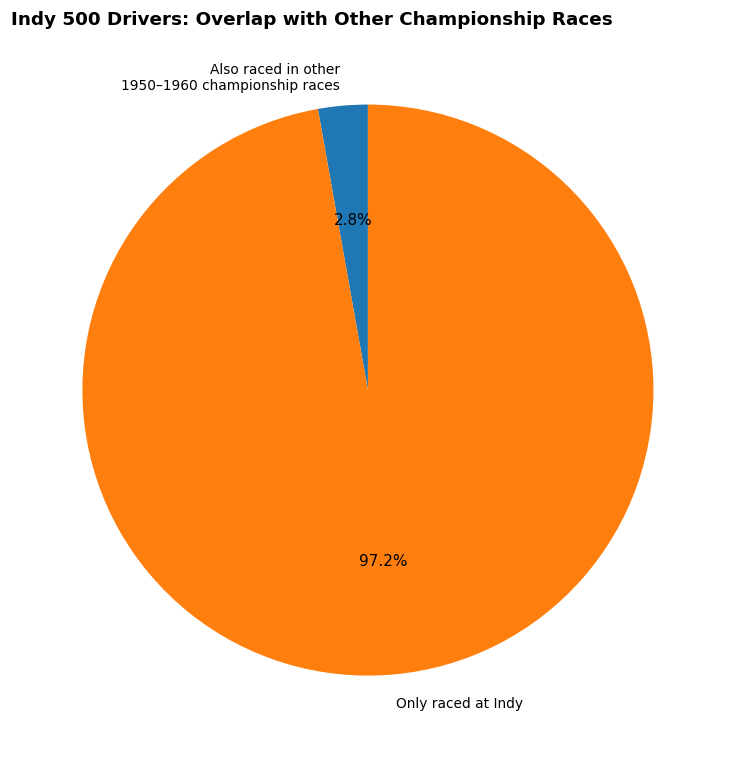

In [19]:
results = clean['results'].merge(clean['races'][['raceId', 'year', 'round', 'name', 'date', 'circuitId']], on='raceId')
row_log = [('raw results', len(results))]              # we track the row count after every cleaning step

indy_ids = set(clean['races'].loc[clean['races']['name'] == 'Indianapolis 500', 'raceId'])
indy = results[results['raceId'].isin(indy_ids)]
others_50s = results[(results['year'] <= 1960) & ~results['raceId'].isin(indy_ids)]

indy_drivers = set(indy['driverId'])
overlap = indy_drivers & set(others_50s['driverId'])
print(f'Indianapolis 500 races: {len(indy_ids)} ({indy["year"].min()} to {indy["year"].max()}), rows: {len(indy)}')
print(f'Drivers who raced at Indy: {len(indy_drivers)}. Of those, raced any other championship race in 1950-1960: {len(overlap)} ({pct(len(overlap) / len(indy_drivers))})')

results = results[~results['raceId'].isin(indy_ids)].copy()
row_log.append(('drop Indianapolis 500', len(results)))

# --- Visualization : Indy drivers vs overlap with other championship races ---
overlap_count = len(overlap)
indy_only_count = len(indy_drivers) - overlap_count

labels = [
    'Also raced in other\n1950–1960 championship races',
    'Only raced at Indy'
]

sizes = [overlap_count, indy_only_count]

plt.figure(figsize=(7, 7))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Indy 500 Drivers: Overlap with Other Championship Races')
plt.tight_layout()
plt.show()

## 2.4 Cars that were not on the grid, and pit-lane starts

Our cutoff is "after qualifying, before the race". At that moment we already know who failed to qualify. Predicting "no podium" for a car that is not allowed to start is not a prediction, so those rows do not belong in the table.

We have to be careful here not to use information from after the cutoff to decide who stays. Our rules:

| Rule | What these rows are | Why |
|---|---|---|
| Drop `positionText == 'F'` (failed to qualify) | known from qualifying | The outcome of qualifying is before the cutoff |
| Drop `grid == 0` and 0 laps completed | never had a grid slot, never raced | Withdrawn or excluded before the start |
| Keep `grid == 0` with laps completed, set grid to missing, add flag `pit_lane_start` | pit-lane starts | They did race. 0 is not a position, so it must not stay as a number |
| Keep withdrawn cars that had a grid slot (`W`, grid > 0) | label = no podium | At the cutoff they were still on the grid. Dropping them would use knowledge from after the cutoff |

A note on honesty: the dataset has no "started from the pit lane" column, so we recognise pit-lane starts by "grid is 0 but the car completed laps". Laps are recorded after the race. We use them only to tell two meanings of the same code apart, never as a feature.

In [20]:
failed_to_qualify = results['positionText'] == 'F'
no_slot_no_race = (results['grid'] == 0) & (results['laps'] == 0) & ~failed_to_qualify
pit_lane = (results['grid'] == 0) & (results['laps'] > 0) & ~failed_to_qualify
kept_withdrawn = (results['positionText'] == 'W') & (results['grid'] > 0)

print(f'Failed to qualify (dropped):               {failed_to_qualify.sum():>5}')
print(f'grid = 0 and never raced (dropped):        {no_slot_no_race.sum():>5}')
print(f'Pit-lane starts (kept, flagged):           {pit_lane.sum():>5}   seasons {results.loc[pit_lane, "year"].min()} to {results.loc[pit_lane, "year"].max()}')
print(f'Withdrawn but had a grid slot (kept):      {kept_withdrawn.sum():>5}')
print(f'Podiums among pit-lane starters:           {(results.loc[pit_lane, "positionOrder"] <= 3).sum():>5}')

results = results[~failed_to_qualify].copy()
row_log.append(('drop failed to qualify', len(results)))
results = results[~((results['grid'] == 0) & (results['laps'] == 0))].copy()
row_log.append(('drop grid 0, never raced', len(results)))

results['pit_lane_start'] = (results['grid'] == 0).astype(int)
results.loc[results['grid'] == 0, 'grid'] = np.nan          # 0 is not a position
assert results['grid'].min() == 1                           # the smallest grid value is now pole position

Failed to qualify (dropped):                1368
grid = 0 and never raced (dropped):          218
Pit-lane starts (kept, flagged):              72   seasons 2015 to 2024
Withdrawn but had a grid slot (kept):        133
Podiums among pit-lane starters:               0


## 2.5 Shared drives: making (raceId, driverId) unique

The brief asks us to choose a rule for which row to keep, apply it, and explain why. We compared three rules instead of just picking one.

What we need from the kept row is the **pre-race** information: which car and which grid slot the driver had when the race started.

| Rule | Idea |
|---|---|
| A. Keep the lowest `resultId` | The dataset stores a driver's original entry first. The rows for cars he took over were added later in a separate block with higher ids |
| B. Keep the best finish (highest `positionOrder`) | Check the final position of each row and keeps the one with the better position |
| C. Keep the highest `resultId` | The opposite of A |

**How we test them:** a grid slot holds one car. After a correct rule, two drivers in the same race should not have the same grid number. We count how often that still happens ("collisions") under each rule. Fewer is better.

**Why did we choose this testing strategy (number of grid-slot collisions) ??**

Simply, because after resolving the duplicate `(raceId, driverId)` records, we want the remaining data to preserve a coherent representation of the race's starting grid. A collision means that multiple driver records are associated with the same grid slot, which is a signal of a shared-car or relief-driver situation. We therefore use the number of collisions as a consistency diagnostic: a rule that leaves fewer collisions produces fewer conflicts in the reconstructed starting-grid representation. 

**So, if we asked, why is lower collisions better, our answer will be as follows:**

Because the collision represents a remaining inconsistency in the one-row-per-driver representation of the starting grid. Therefore, fewer collisions means the rule resolves the duplicate records with fewer such inconsistencies.

Duplicated pairs left after 2.3 and 2.4: 61 in 36 races


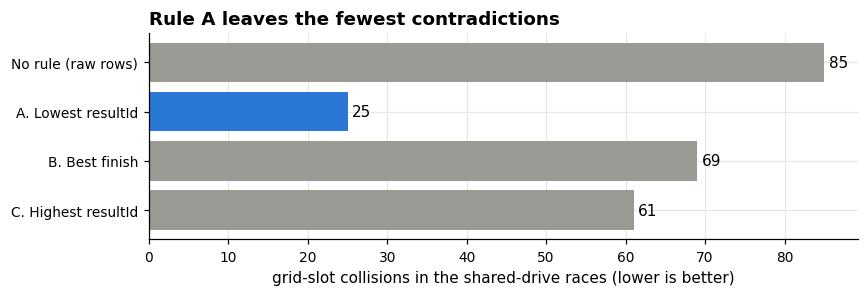

Fangio, Argentina 1956. Rule A keeps grid 1 | Rule B keeps grid 3 (he started from pole, grid 1)


In [21]:
dup_mask = results.duplicated(['raceId', 'driverId'], keep=False)
# the races that contain at least one driver with more than one row
shared_races = results.loc[dup_mask, 'raceId'].unique()
pool = results[results['raceId'].isin(shared_races)]         # only the races that have shared drives
print(f'Duplicated pairs left after 2.3 and 2.4: {results[dup_mask].drop_duplicates(["raceId", "driverId"]).shape[0]} in {len(shared_races)} races')

def collisions(df):
    """Number of rows that share a (race, grid slot) with an earlier row."""
    on_grid = df[df['grid'].notna()]
    return int(on_grid.duplicated(['raceId', 'grid']).sum())

# Apply each candidate rule to the same rows. sort_values + drop_duplicates keeps one row per driver per race
rules = {
    'No rule (raw rows)': pool,
    'A. Lowest resultId': pool.sort_values('resultId').drop_duplicates(['raceId', 'driverId'], keep='first'),
    'B. Best finish': pool.sort_values('positionOrder').drop_duplicates(['raceId', 'driverId'], keep='first'),
    'C. Highest resultId': pool.sort_values('resultId').drop_duplicates(['raceId', 'driverId'], keep='last'),
}
# Score every rule by its number of collisions
rule_scores = pd.Series({name: collisions(df) for name, df in rules.items()})

fig, ax = plt.subplots(figsize=(8, 2.8))
bars = ax.barh(rule_scores.index[::-1], rule_scores.values[::-1],
               color=[BLUE if n.startswith('A') else GREY for n in rule_scores.index[::-1]])
ax.bar_label(bars, padding=3)
ax.set_xlabel('grid-slot collisions in the shared-drive races (lower is better)')
ax.set_title('Rule A leaves the fewest contradictions')
finish(fig, '09_duplicate_rules')

# The same Fangio example under rule A and rule B
ex = pool[(pool['driverId'].astype(str) == str(fangio)) & (pool['year'] == 1956) & (pool['name'] == 'Argentine Grand Prix')]
print('Fangio, Argentina 1956. Rule A keeps grid', int(ex.sort_values('resultId')['grid'].iloc[0]),
      '| Rule B keeps grid', int(ex.sort_values('positionOrder')['grid'].iloc[0]), '(he started from pole, grid 1)')

**What we see:** rule A leaves the fewest contradictions by a wide margin, and it gives the historically correct pole position for Fangio. Rule B picks the wrong car and, on top of that, it chooses a pre-race value by looking at the result. So, as a result, we chose to use rule A.

The collisions that remain under rule A are not duplicates at all. They are relief drivers who took over a car and have a single row, which carries the grid slot of the car and not their own. No duplicate rule can fix those. So, we count them below and list them as a limitation.

**The label needs a second decision.** If a driver's first car retired and the car he took over finished 2nd, the official record credits him with a podium. So:
- **features** (grid, team, car number) come from the row we keep, his own starting car
- **label** `podium` = 1 if *any* of his rows in that race finished in the top 3
- points are summed over his rows, and his finishing position is the best of his rows

This keeps the features strictly pre-race and the label equal to the official record.

In [22]:
# Race-level outcome per driver, computed over ALL of his rows in that race
outcome = results.groupby(['raceId', 'driverId']).agg(
    best_order=('positionOrder', 'min'),                                  # best finishing rank of any car he drove
    points=('points', 'sum'),                                             # shared drives gave points for each car
    classified=('positionText', lambda s: int(s.str.isdigit().any())),    # 1 if he was classified in any car
    n_rows=('resultId', 'size'),
).reset_index()
outcome['podium'] = (outcome['best_order'] <= 3).astype(int)              # the target, as defined in the brief

# Rule A: keep the row with the lowest resultId (his own starting car)
first_rows = results.sort_values('resultId').drop_duplicates(['raceId', 'driverId'], keep='first')
label_of_kept_row = (first_rows.set_index(['raceId', 'driverId'])['positionOrder'] <= 3).astype(int)

results_clean = first_rows.drop(columns=['points']).merge(outcome, on=['raceId', 'driverId'], how='left', validate='one_to_one')
row_log.append(('one row per driver per race', len(results_clean)))

# --- Checks ---
assert not results_clean.duplicated(['raceId', 'driverId']).any(), 'grain is still not unique'
assert results_clean['podium'].notna().all()
changed = int((results_clean.set_index(['raceId', 'driverId'])['podium'] != label_of_kept_row).sum())
relief = int(rule_scores['A. Lowest resultId'])
print(f'Rows removed as duplicates: {row_log[-2][1] - row_log[-1][1]}')
print(f'Drivers credited with a podium through a car they took over (label would be wrong without the "any row" rule): {changed}')
print(f'Relief drivers who inherit the grid slot of the car they took over (documented limitation): {relief}')
print(f'Final table: {len(results_clean):,} rows, (raceId, driverId) is unique.')

Rows removed as duplicates: 64
Drivers credited with a podium through a car they took over (label would be wrong without the "any row" rule): 15
Relief drivers who inherit the grid slot of the car they took over (documented limitation): 25
Final table: 24,704 rows, (raceId, driverId) is unique.


## 2.6 Did the cleaning do what we wanted? EDA after cleaning
The brief asks for the EDA before and after cleaning, to see the impact. We repeat the same measurements and put them next to each other.

,step,rows,removed
0,raw results,26759,0
1,drop Indianapolis 500,26354,405
2,drop failed to qualify,24986,1368
3,"drop grid 0, never raced",24768,218
4,one row per driver per race,24704,64


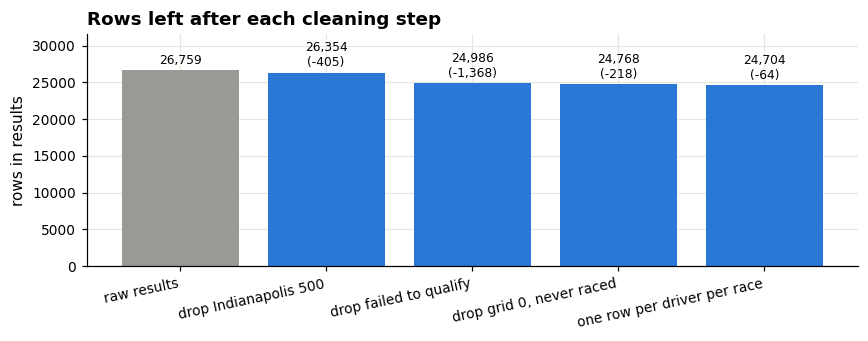

In [23]:
# --- (a) Row count after each step ---
steps = pd.DataFrame(row_log, columns=['step', 'rows'])
steps['removed'] = -steps['rows'].diff().fillna(0).astype(int)
display(steps)

fig, ax = plt.subplots(figsize=(8, 3.2))
bars = ax.bar(steps['step'], steps['rows'], color=[GREY] + [BLUE] * (len(steps) - 1))
ax.bar_label(bars, labels=[f'{r:,}' + (f'\n(-{d:,})' if d else '') for r, d in zip(steps['rows'], steps['removed'])], fontsize=8, padding=2)
ax.set_ylim(0, steps['rows'].max() * 1.18); ax.set_ylabel('rows in results')
plt.setp(ax.get_xticklabels(), rotation=12, ha='right')
ax.set_title('Rows left after each cleaning step')
finish(fig, '10_rows_per_step')

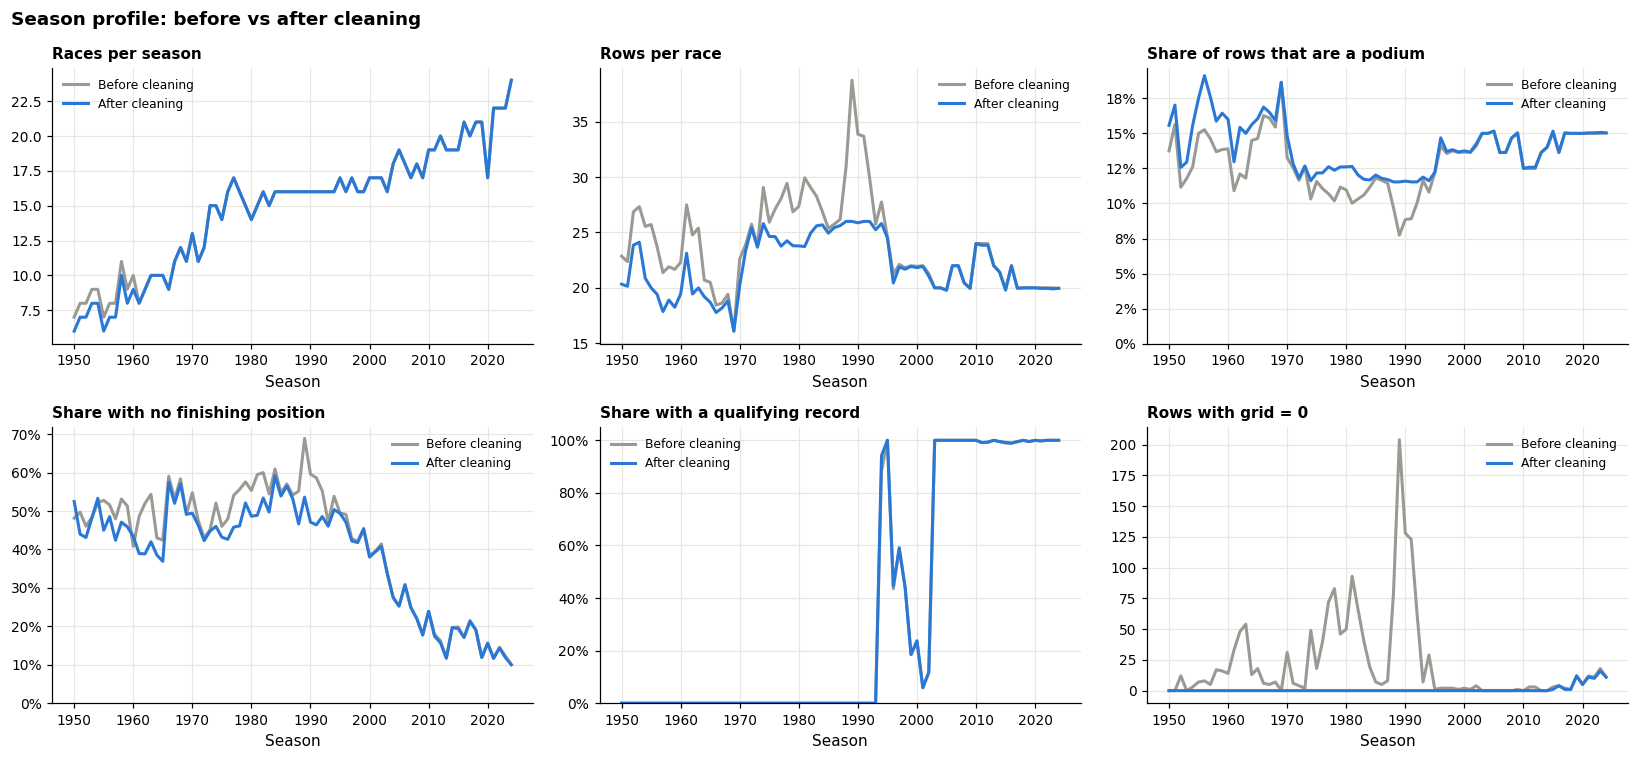

,before cleaning,after cleaning
rows in results,26759,24704
placeholder cells (all tables),160144,0
"duplicated (raceId, driverId) pairs",85,0
rows with grid = 0,1638,0
smallest grid value,0,1
text columns in results,18,3
podium share of rows,12.7%,13.6%
podium drivers per race (mean),3.02,3.02


In [24]:
# --- (b) The same season profile as in 1.7, before vs after ---
# season_profile expects the raw column names, so we pass the cleaned values under those names
profile_after = season_profile(results_clean.assign(positionOrder=results_clean['best_order'],
                                                    grid=results_clean['grid'].fillna(0)), clean['qualifying'])
# Same six measurements used in Section 1.7
panels = [
    ('races', 'Races per season', 'count'),
    ('rows_per_race', 'Rows per race', 'count'),
    ('podium_share', 'Share of rows that are a podium', 'share'),
    ('not_classified_share', 'Share with no finishing position', 'share'),
    ('quali_coverage', 'Share with a qualifying record', 'share'),
    ('grid0_rows', 'Rows with grid = 0', 'count')
]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))

for ax, (col, title, unit) in zip(axes.ravel(), panels):
    # Before cleaning
    ax.plot(profile_before.index, profile_before[col], color=GREY, lw=2, label='Before cleaning')

    # After cleaning
    ax.plot(profile_after.index, profile_after[col], color=BLUE, lw=2, label='After cleaning')

    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Season')

    if unit == 'share':
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
        ax.set_ylim(bottom=0)

    ax.legend(fontsize=8)

fig.suptitle('Season profile: before vs after cleaning', x=0.01, ha='left', weight='bold')

plt.tight_layout()
finish(fig, '11_season_profile_before_after')

# --- (c) A compact before / after table ---
before_after = pd.DataFrame({
    'before cleaning': {
        'rows in results': len(raw['results']),
        'placeholder cells (all tables)': placeholders_before,
        'duplicated (raceId, driverId) pairs': n_groups,
        'rows with grid = 0': int((raw['results']['grid'] == '0').sum()),
        'smallest grid value': int(raw['results']['grid'].min()),
        'text columns in results': int((dtypes_before['results'] != 'int64').sum()),
        'podium share of rows': pct((raw['results']['positionOrder'].astype(int) <= 3).mean()),
        'podium drivers per race (mean)': round((raw['results']['positionOrder'].astype(int) <= 3).sum() / raw['results']['raceId'].nunique(), 2),
    },
    'after cleaning': {
        'rows in results': len(results_clean),
        'placeholder cells (all tables)': placeholders_left,
        'duplicated (raceId, driverId) pairs': int(results_clean.duplicated(['raceId', 'driverId']).sum()),
        'rows with grid = 0': int((results_clean['grid'] == '0').sum()),
        'smallest grid value': int(results_clean['grid'].min()),
        'text columns in results': int(sum(not pd.api.types.is_numeric_dtype(clean['results'][c]) for c in raw['results'].columns)),
        'podium share of rows': pct(results_clean['podium'].mean()),
        'podium drivers per race (mean)': round(results_clean['podium'].sum() / results_clean['raceId'].nunique(), 2),
    }})
display(before_after)

In [25]:
# --- (d) Sanity check against facts we know from outside the dataset ---
# If the cleaning broke something, well-known career numbers would no longer match.
def driver_id(ref):
    return int(clean['drivers'].loc[clean['drivers']['driverRef'] == ref, 'driverId'].iloc[0])

facts = {
    'Hamilton career podiums up to 2024': (results_clean.loc[results_clean['driverId'] == driver_id('hamilton'), 'podium'].sum(), 202),
    'M. Schumacher career podiums': (results_clean.loc[results_clean['driverId'] == driver_id('michael_schumacher'), 'podium'].sum(), 155),
    'Verstappen podiums in 2023': (results_clean.loc[(results_clean['driverId'] == driver_id('max_verstappen')) & (results_clean['year'] == 2023), 'podium'].sum(), 21),
    'Fangio career podiums (shared drives included)': (results_clean.loc[results_clean['driverId'] == driver_id('fangio'), 'podium'].sum(), 35),
    'Fangio career wins': ((results_clean.loc[results_clean['driverId'] == driver_id('fangio'), 'best_order'] == 1).sum(), 24),
}
fact_table = pd.DataFrame(facts, index=['our table', 'official record']).T
fact_table['match'] = fact_table['our table'] == fact_table['official record']
display(fact_table)
assert fact_table['match'].all(), 'Cleaning changed a known career statistic'

# Last check on grid: outside the shared-drive races, is every grid slot used by one car only?
others = results_clean[~results_clean['raceId'].isin(shared_races) & results_clean['grid'].notna()]
clash = others[others.duplicated(['raceId', 'grid'], keep=False)]
print(f'Grid slots listed for two cars outside shared-drive races: {clash.drop_duplicates(["raceId", "grid"]).shape[0]} slots, '
      f'{len(clash)} rows ({pct(len(clash) / len(results_clean))} of the table). Left as they are in the source.')

,our table,official record,match
Hamilton career podiums up to 2024,202,202,True
M. Schumacher career podiums,155,155,True
Verstappen podiums in 2023,21,21,True
Fangio career podiums (shared drives included),35,35,True
Fangio career wins,24,24,True


Grid slots listed for two cars outside shared-drive races: 71 slots, 142 rows (0.6% of the table). Left as they are in the source.


**What we see**
- 26,759 rows became 24,704. Most of the removed rows are cars that failed to qualify.
- The "cars per race" line is now much flatter. Before cleaning it reached almost 39 in 1989 because of non-qualifiers. After cleaning the 1980s sit at about 26, which was the real size of the grid then.
- The podium share went up a little everywhere, because we removed rows that could never be a podium.
- Grid = 0 is gone as a number. The blue line in the third chart counts the 72 pit-lane starts that are now a flag.
- Podium drivers per race is slightly above 3. That is correct: in a shared drive two drivers were credited with the same podium.
- The career numbers of Hamilton, Schumacher, Verstappen and Fangio match the official records. Fangio is the important one, because he has more than one row in 7 of his races. Our "any row" label rule gives his official 35 podiums and 24 wins.
- One thing cleaning cannot fix: in races without shared drives, the source lists 71 grid slots for two different cars each (142 rows, 0.6% of the table). We cannot tell which of the two is right, so we leave them and list it as a limitation.

In [26]:
# Fangio's rows at the 1956 Argentine Grand Prix
fangio_rows = res_raw[
    (res_raw['driverId'] == fangio) &
    (res_raw['year'] == 1956) &
    (res_raw['name'] == 'Argentine Grand Prix')
]

# Find the other driver associated with each of Fangio's cars
for _, row in fangio_rows.iterrows():
    car_number = row['number']
    fangio_result_id = row['resultId']

    other_driver_ids = res_raw[
        (res_raw['year'] == 1956) &
        (res_raw['name'] == 'Argentine Grand Prix') &
        (res_raw['number'] == car_number) &
        (res_raw['driverId'] != fangio) &
        (res_raw['resultId'] < fangio_result_id)
    ]['driverId'].unique()

    for driver_id in other_driver_ids:
        driver_name = raw['drivers'].loc[
            raw['drivers']['driverId'] == driver_id,
            ['forename', 'surname']
        ]

        print(
            f"\nAll rows for {driver_name.iloc[0]['forename']} "
            f"{driver_name.iloc[0]['surname']} "
            f"(car number {car_number}) at the 1956 Argentine Grand Prix:"
        )

        display(
            res_raw[
                (res_raw['driverId'] == driver_id) &
                (res_raw['year'] == 1956) &
                (res_raw['name'] == 'Argentine Grand Prix')
            ]
        )


All rows for Luigi Musso (car number 34) at the 1956 Argentine Grand Prix:


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,year,name,outcome
18882,18883,784,577,6,34,3,1,1,1,4,98,3:00:03.7,10803700,\N,\N,\N,\N,1,1956,Argentine Grand Prix,finished (has a position)


# 3. One joined table
**What we do**: join the cleaned results with races, circuits, drivers, constructors, status and qualifying, and add the sprint points from sprint_results.

**Why**: the facts we need are spread over eight tables. After this step every row has everything about one driver in one race.

**How we protect the grain**: after each join we assert that the number of rows did not change. validate='many_to_one' makes pandas itself raise an error if the right-hand table has duplicate keys. Qualifying is a left join, because most rows before 2003 have no qualifying record and we must not lose them.

In [27]:
n0 = len(results_clean)
# Start from the cleaned results only, then add the other tables one validated join at a time
base = results_clean.drop(columns=['year', 'round', 'name', 'date', 'circuitId']).copy()

def safe_join(left, right, on, how='left', validate='many_to_one'):
    """Join and prove that no row was added or lost."""
    out = left.merge(right, on=on, how=how, validate=validate)
    assert len(out) == len(left), f'row count changed in join on {on}'
    return out

# results -> races -> circuits -> drivers -> constructors -> status. Each join adds columns, never rows
base = safe_join(base, clean['races'][['raceId', 'year', 'round', 'date', 'circuitId', 'name']].rename(columns={'name': 'race_name'}), 'raceId')
base = safe_join(base, clean['circuits'][['circuitId', 'name', 'country']].rename(columns={'name': 'circuit', 'country': 'circuit_country'}), 'circuitId')
base = safe_join(base, clean['drivers'][['driverId', 'driverRef', 'forename', 'surname', 'dob', 'nationality']], 'driverId')
base = safe_join(base, clean['constructors'][['constructorId', 'name']].rename(columns={'name': 'team'}), 'constructorId')
base = safe_join(base, clean['status'], 'statusId')
# qualifying: joined on the pair (raceId, driverId). Rows without a qualifying record get NaN
quali = clean['qualifying'][['raceId', 'driverId', 'position', 'q1_s', 'q2_s', 'q3_s']].rename(columns={'position': 'q_pos'})
base = safe_join(base, quali, ['raceId', 'driverId'], validate='one_to_one')
# Sprint points count for the championship. We only need them to keep the standings of LATER weekends correct (5.3).
sprint_points = clean['sprint_results'].groupby(['raceId', 'driverId'], as_index=False)['points'].sum().rename(columns={'points': 'sprint_points'})
base = safe_join(base, sprint_points, ['raceId', 'driverId'], validate='one_to_one')
base['sprint_points'] = base['sprint_points'].fillna(0)

base['driver'] = base['forename'] + ' ' + base['surname']
base = base.sort_values(['date', 'raceId', 'resultId']).reset_index(drop=True)      # strict time order

assert len(base) == n0 and not base.duplicated(['raceId', 'driverId']).any()
print(f'Base table: {len(base):,} rows x {base.shape[1]} columns, one row per driver per race.')
print(f'Seasons {base["year"].min()} to {base["year"].max()}, {base["raceId"].nunique()} races, {base["driverId"].nunique()} drivers, {base["constructorId"].nunique()} teams.')
print(f'Podium rows: {base["podium"].sum():,} ({pct(base["podium"].mean())})')
display(base[['year', 'race_name', 'driver', 'team', 'grid', 'q_pos', 'best_order', 'podium', 'status']].tail(5))

Base table: 24,704 rows x 44 columns, one row per driver per race.
Seasons 1950 to 2024, 1114 races, 686 drivers, 167 teams.
Podium rows: 3,359 (13.6%)


,year,race_name,driver,team,grid,q_pos,best_order,podium,status
24699,2024,Abu Dhabi Grand Prix,Kevin Magnussen,Haas F1 Team,14.0,15.0,16,0,+1 Lap
24700,2024,Abu Dhabi Grand Prix,Liam Lawson,RB F1 Team,12.0,12.0,17,0,Engine
24701,2024,Abu Dhabi Grand Prix,Valtteri Bottas,Sauber,9.0,9.0,18,0,Collision damage
24702,2024,Abu Dhabi Grand Prix,Franco Colapinto,Williams,20.0,19.0,19,0,Engine
24703,2024,Abu Dhabi Grand Prix,Sergio Pérez,Red Bull,10.0,10.0,20,0,Collision


## 3.1 Which columns are allowed? The leakage map
The brief says part of the milestone is learning to spot which fields are "future" information. We went through every source and asked one question: **is this value known after qualifying and before the start?**

The table below is our answer. The rule we follow for the rest of the notebook: a red column of the current race can be used as the label or to build history for later races, and never as a feature of its own race.

In [28]:
# One line per group of columns: where it comes from, whether it is known before the race, and how we use it
leakage_map = pd.DataFrame([
    ('results', 'grid', 'yes', 'feature', 'The grid is published before the start'),
    ('results', 'constructorId, number', 'yes', 'keys for joins and team history', 'Entry list is known before the weekend'),
    ('qualifying', 'position, q1, q2, q3', 'yes', 'features', 'Qualifying is finished at the cutoff'),
    ('races / circuits', 'year, round, date, circuit, country', 'yes', 'features and time ordering', 'The calendar is fixed in advance'),
    ('drivers', 'dob, nationality', 'yes', 'features (age, home race)', 'Does not change'),
    ('results', 'position, positionText, positionOrder', 'NO', 'label, and history for later races', 'This is the result itself'),
    ('results', 'points', 'NO', 'history for later races only', 'Awarded after the race'),
    ('results', 'laps, time, milliseconds', 'NO', 'not used as a feature', 'Recorded during the race'),
    ('results', 'fastestLap, rank, fastestLapTime, fastestLapSpeed', 'NO', 'not used', 'Recorded during the race'),
    ('results', 'statusId', 'NO', 'Question 3, and history for later races', 'Says how the race ended'),
    ('driver_standings / constructor_standings', 'points, position, wins', 'NO', 'not used. We rebuild standings ourselves (5.3)', 'Stored AFTER each race, so they contain its result'),
    ('constructor_results', 'points', 'NO', 'not used', 'Awarded after the race'),
    ('lap_times, pit_stops', 'everything', 'NO', 'not used', 'Recorded during the race'),
    ('sprint_results', 'position, grid, times', 'yes (sprint is before the race)', 'not used', 'Allowed, but only 18 weekends have a sprint (see 5.1)'),
    ('sprint_results', 'points', 'yes (sprint is before the race)', 'standings of later weekends only', 'Sprint points count for the championship'),
], columns=['table', 'columns', 'known before the race?', 'how we use it', 'reason'])

# green row = allowed at the cutoff, red row = not allowed
def colour(row):
    bad = row['known before the race?'] == 'NO'
    return ['background-color: #fde3e3' if bad else 'background-color: #e3f4ec'] * len(row)
display(leakage_map.style.apply(colour, axis=1).hide(axis='index'))

table,columns,known before the race?,how we use it,reason
results,grid,yes,feature,The grid is published before the start
results,"constructorId, number",yes,keys for joins and team history,Entry list is known before the weekend
qualifying,"position, q1, q2, q3",yes,features,Qualifying is finished at the cutoff
races / circuits,"year, round, date, circuit, country",yes,features and time ordering,The calendar is fixed in advance
drivers,"dob, nationality",yes,"features (age, home race)",Does not change
results,"position, positionText, positionOrder",NO,"label, and history for later races",This is the result itself
results,points,NO,history for later races only,Awarded after the race
results,"laps, time, milliseconds",NO,not used as a feature,Recorded during the race
results,"fastestLap, rank, fastestLapTime, fastestLapSpeed",NO,not used,Recorded during the race
results,statusId,NO,"Question 3, and history for later races",Says how the race ended
